In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# 设置全局字体，支持中文
plt.rcParams["font.family"] = ["SimHei", "WenQuanYi Micro Hei", "Heiti TC"]
# 解决负号显示问题
plt.rcParams["axes.unicode_minus"] = False

# 读取数据
df = pd.read_csv('tetuan_bk_1763566192725.csv')

# 查看数据基本信息
print("数据形状:", df.shape)
print("\n前5行数据:")
print(df.head())
print("\n数据类型:")
print(df.dtypes)
print("\n缺失值统计:")
print(df.isnull().sum())

数据形状: (52416, 6)

前5行数据:
              X1     X2    X3     X4     X5            Y
0  1/1/2017 0:00  6.559  73.8  0.083  0.119  34055.69620
1  1/1/2017 0:10  6.414  74.5  0.083  0.085  29814.68354
2  1/1/2017 0:20  6.313  74.5  0.080  0.100  29128.10127
3  1/1/2017 0:30  6.121  75.0  0.083  0.096  28228.86076
4  1/1/2017 0:40  5.921  75.7  0.081  0.085  27335.69620

数据类型:
X1     object
X2    float64
X3    float64
X4    float64
X5    float64
Y     float64
dtype: object

缺失值统计:
X1    0
X2    0
X3    0
X4    0
X5    0
Y     0
dtype: int64


In [2]:
# 将X1转换为datetime格式
df['X1'] = pd.to_datetime(df['X1'], format="%m/%d/%Y %H:%M")

# --- 1. 提取时间特征 ---
print("开始提取时间特征...")
df['hour'] = df['X1'].dt.hour
df['dayofweek'] = df['X1'].dt.dayofweek
df['month'] = df['X1'].dt.month
df['dayofyear'] = df['X1'].dt.dayofyear
print("时间特征提取完成。新增列：'hour', 'dayofweek', 'month', 'dayofyear'\n")



开始提取时间特征...
时间特征提取完成。新增列：'hour', 'dayofweek', 'month', 'dayofyear'



In [3]:
from sklearn.preprocessing import StandardScaler

# 选择特征列进行标准化
features = ['X2', 'X3', 'X4', 'X5', 'hour', 'dayofweek', 'month', 'dayofyear']
scaler = StandardScaler()
df[features] = scaler.fit_transform(df[features])

In [5]:
from sklearn.model_selection import train_test_split

# 定义特征和目标变量
X = df[features]
y = df['Y']

# 按3:1分割训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, shuffle=False)

print("训练集形状:", X_train.shape)
print("测试集形状:", X_test.shape)

训练集形状: (39312, 8)
测试集形状: (13104, 8)


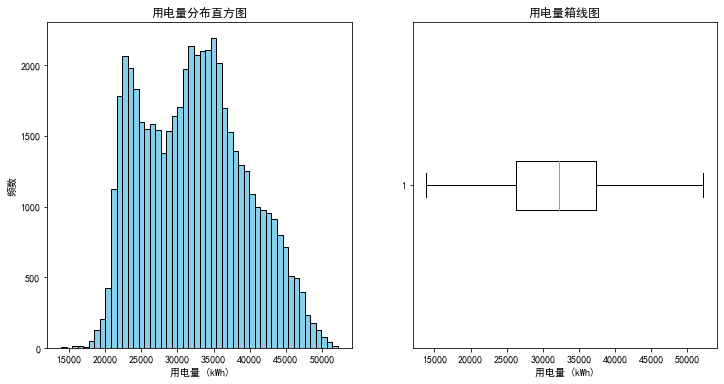

In [6]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(df['Y'], bins=50, color='skyblue', edgecolor='black')
plt.title('用电量分布直方图')
plt.xlabel('用电量 (kWh)')
plt.ylabel('频数')

plt.subplot(1, 2, 2)
plt.boxplot(df['Y'], vert=False)
plt.title('用电量箱线图')
plt.xlabel('用电量 (kWh)')
plt.show()

特征与用电量的相关系数:
Y            1.000000
hour         0.727953
X2           0.440221
X4           0.167444
X5           0.080274
dayofyear   -0.003908
month       -0.005346
dayofweek   -0.069708
X3          -0.287421
Name: Y, dtype: float64


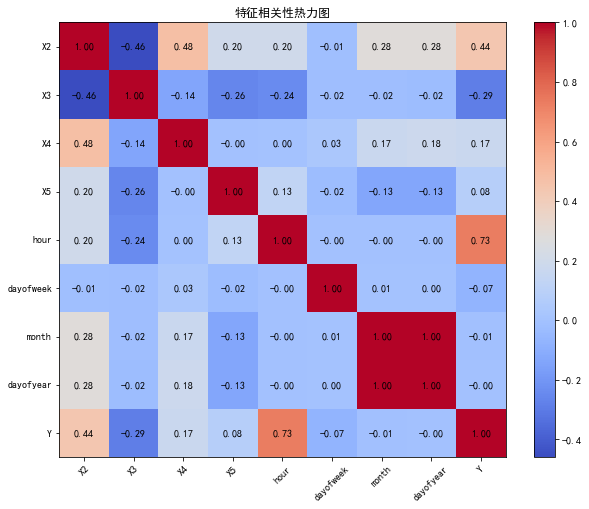

In [7]:
# 计算相关系数
correlation = df[features + ['Y']].corr()
print("特征与用电量的相关系数:")
print(correlation['Y'].sort_values(ascending=False))

# 绘制热力图
plt.figure(figsize=(10, 8))
plt.imshow(correlation, cmap='coolwarm', interpolation='none', aspect='auto')
plt.colorbar()
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)
plt.title('特征相关性热力图')

# 在热力图上显示相关系数
for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        plt.text(j, i, f'{correlation.iloc[i, j]:.2f}', ha='center', va='center', color='black')
plt.show()

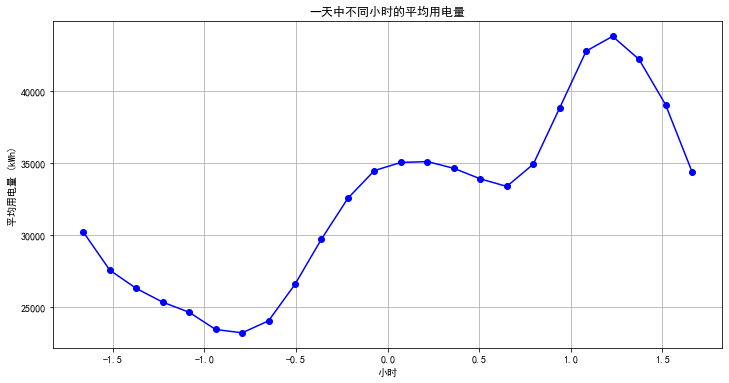

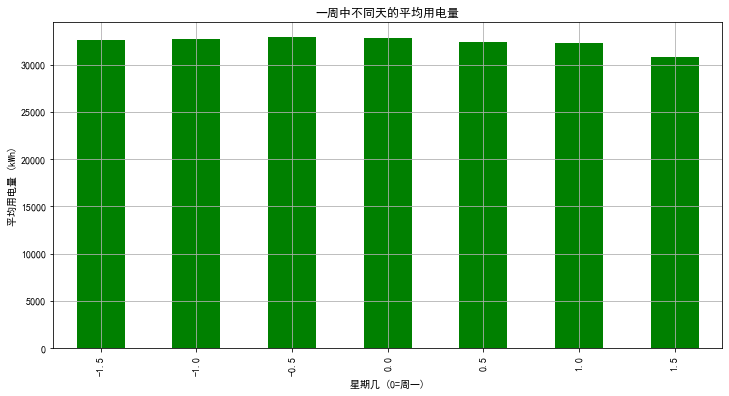

In [8]:
# 按小时聚合用电量
hourly_consumption = df.groupby('hour')['Y'].mean()
plt.figure(figsize=(12, 6))
hourly_consumption.plot(kind='line', marker='o', color='blue')
plt.title('一天中不同小时的平均用电量')
plt.xlabel('小时')
plt.ylabel('平均用电量 (kWh)')
plt.grid(True)
plt.show()

# 按星期几聚合用电量
daily_consumption = df.groupby('dayofweek')['Y'].mean()
plt.figure(figsize=(12, 6))
daily_consumption.plot(kind='bar', color='green')
plt.title('一周中不同天的平均用电量')
plt.xlabel('星期几 (0=周一)')
plt.ylabel('平均用电量 (kWh)')
plt.grid(True)
plt.show()

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 初始化模型
lr_model = LinearRegression()

# 训练模型
lr_model.fit(X_train, y_train)

# 预测
y_pred_lr = lr_model.predict(X_test)

# 评估模型
lr_mse = mean_squared_error(y_test, y_pred_lr)
lr_r2 = r2_score(y_test, y_pred_lr)

print("多元线性回归模型评估:")
print(f"均方误差 (MSE): {lr_mse:.2f}")
print(f"决定系数 (R²): {lr_r2:.2f}")

# 查看特征系数
coef_df = pd.DataFrame({
    '特征': features,
    '系数': lr_model.coef_
})
print("\n特征系数:")
print(coef_df.sort_values(by='系数', ascending=False))

多元线性回归模型评估:
均方误差 (MSE): 16376120.53
决定系数 (R²): 0.61

特征系数:
          特征           系数
4       hour  4933.002462
0         X2  2209.905218
7  dayofyear  1736.364274
1         X3    64.837102
2         X4     0.776166
5  dayofweek  -485.641446
3         X5  -640.657953
6      month -1933.854543


In [10]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# 初始化模型
ridge_model = Ridge()

# 设置超参数网格
param_grid = {'alpha': [0.1, 1, 10, 100, 1000]}

# 网格搜索
grid_search = GridSearchCV(ridge_model, param_grid, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)

# 最佳模型
best_ridge = grid_search.best_estimator_

# 预测
y_pred_ridge = best_ridge.predict(X_test)

# 评估模型
ridge_mse = mean_squared_error(y_test, y_pred_ridge)
ridge_r2 = r2_score(y_test, y_pred_ridge)

print("岭回归模型评估:")
print(f"最佳超参数 alpha: {grid_search.best_params_['alpha']}")
print(f"均方误差 (MSE): {ridge_mse:.2f}")
print(f"决定系数 (R²): {ridge_r2:.2f}")

岭回归模型评估:
最佳超参数 alpha: 1000
均方误差 (MSE): 17508244.28
决定系数 (R²): 0.58


In [11]:
from sklearn.linear_model import Lasso

# 初始化模型
lasso_model = Lasso()

# 设置超参数网格
param_grid = {'alpha': [0.1, 1, 10, 100, 1000]}

# 网格搜索
grid_search = GridSearchCV(lasso_model, param_grid, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)

# 最佳模型
best_lasso = grid_search.best_estimator_

# 预测
y_pred_lasso = best_lasso.predict(X_test)

# 评估模型
lasso_mse = mean_squared_error(y_test, y_pred_lasso)
lasso_r2 = r2_score(y_test, y_pred_lasso)

print("Lasso回归模型评估:")
print(f"最佳超参数 alpha: {grid_search.best_params_['alpha']}")
print(f"均方误差 (MSE): {lasso_mse:.2f}")
print(f"决定系数 (R²): {lasso_r2:.2f}")

# 查看特征系数
coef_df = pd.DataFrame({
    '特征': features,
    '系数': best_lasso.coef_
})
print("\n特征系数:")
print(coef_df.sort_values(by='系数', ascending=False))

Lasso回归模型评估:
最佳超参数 alpha: 100
均方误差 (MSE): 17877616.15
决定系数 (R²): 0.57

特征系数:
          特征           系数
4       hour  4844.577301
0         X2  1978.244885
1         X3    -0.000000
2         X4     0.000000
6      month     0.000000
7  dayofyear     0.000000
5  dayofweek  -386.390361
3         X5  -514.023056


In [12]:
from sklearn.ensemble import RandomForestRegressor

# 初始化模型
rf_model = RandomForestRegressor(random_state=42)

# 设置超参数网格
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# 网格搜索
grid_search = GridSearchCV(rf_model, param_grid, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)

# 最佳模型
best_rf = grid_search.best_estimator_

# 预测
y_pred_rf = best_rf.predict(X_test)

# 评估模型
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)

print("随机森林回归模型评估:")
print(f"最佳超参数: {grid_search.best_params_}")
print(f"均方误差 (MSE): {rf_mse:.2f}")
print(f"决定系数 (R²): {rf_r2:.2f}")

# 查看特征重要性
feature_importance = pd.DataFrame({
    '特征': features,
    '重要性': best_rf.feature_importances_
})
print("\n特征重要性:")
print(feature_importance.sort_values(by='重要性', ascending=False))

随机森林回归模型评估:
最佳超参数: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 300}
均方误差 (MSE): 18838492.58
决定系数 (R²): 0.55

特征重要性:
          特征       重要性
4       hour  0.811665
7  dayofyear  0.141236
5  dayofweek  0.015676
0         X2  0.012806
3         X5  0.012281
1         X3  0.002663
2         X4  0.001839
6      month  0.001834


In [13]:
import xgboost as xgb

# 初始化模型
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# 设置超参数网格
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 10],
    'learning_rate': [0.01, 0.1, 0.3]
}

# 网格搜索
grid_search = GridSearchCV(xgb_model, param_grid, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)

# 最佳模型
best_xgb = grid_search.best_estimator_

# 预测
y_pred_xgb = best_xgb.predict(X_test)

# 评估模型
xgb_mse = mean_squared_error(y_test, y_pred_xgb)
xgb_r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost回归模型评估:")
print(f"最佳超参数: {grid_search.best_params_}")
print(f"均方误差 (MSE): {xgb_mse:.2f}")
print(f"决定系数 (R²): {xgb_r2:.2f}")

# 查看特征重要性
xgb_feature_importance = pd.DataFrame({
    '特征': features,
    '重要性': best_xgb.feature_importances_
})
print("\n特征重要性:")
print(xgb_feature_importance.sort_values(by='重要性', ascending=False))

XGBoost回归模型评估:
最佳超参数: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
均方误差 (MSE): 14579170.64
决定系数 (R²): 0.65

特征重要性:
          特征       重要性
4       hour  0.753365
7  dayofyear  0.091745
5  dayofweek  0.040089
0         X2  0.039326
6      month  0.034324
3         X5  0.030929
2         X4  0.006026
1         X3  0.004195


模型性能对比:
        模型           MSE        R²
4  XGBoost  1.457917e+07  0.650191
0   多元线性回归  1.637612e+07  0.607075
1      岭回归  1.750824e+07  0.579911
2  Lasso回归  1.787762e+07  0.571049
3     随机森林  1.883849e+07  0.547994


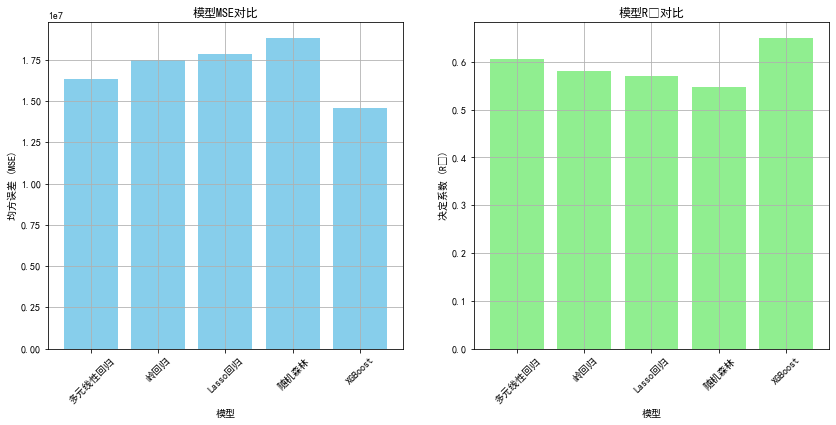

In [14]:
# 汇总所有模型的评估结果
models = ['多元线性回归', '岭回归', 'Lasso回归', '随机森林', 'XGBoost']
mse_scores = [lr_mse, ridge_mse, lasso_mse, rf_mse, xgb_mse]
r2_scores = [lr_r2, ridge_r2, lasso_r2, rf_r2, xgb_r2]

# 创建对比表格
results_df = pd.DataFrame({
    '模型': models,
    'MSE': mse_scores,
    'R²': r2_scores
})
print("模型性能对比:")
print(results_df.sort_values(by='R²', ascending=False))

# 可视化对比
plt.figure(figsize=(14, 6))

# MSE对比
plt.subplot(1, 2, 1)
plt.bar(models, mse_scores, color='skyblue')
plt.title('模型MSE对比')
plt.xlabel('模型')
plt.ylabel('均方误差 (MSE)')
plt.xticks(rotation=45)
plt.grid(True)

# R²对比
plt.subplot(1, 2, 2)
plt.bar(models, r2_scores, color='lightgreen')
plt.title('模型R²对比')
plt.xlabel('模型')
plt.ylabel('决定系数 (R²)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

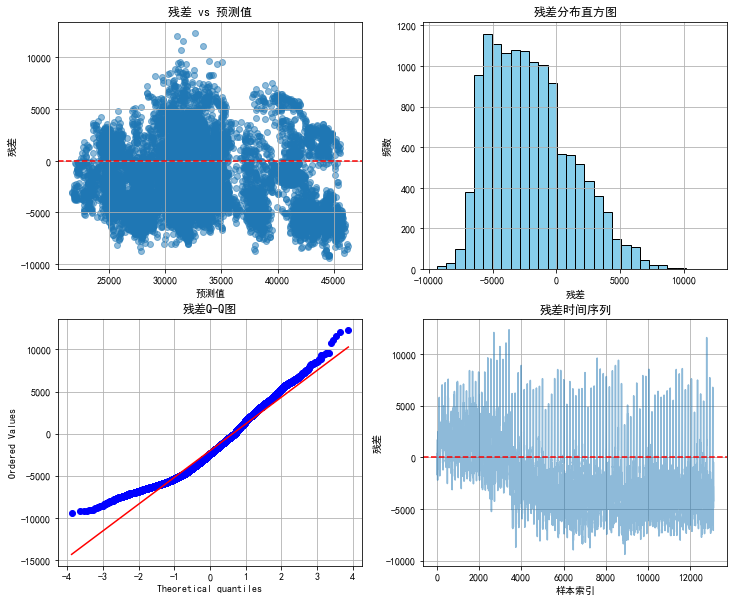

In [15]:
# 选择R²最高的模型进行残差分析
best_model_name = results_df.sort_values(by='R²', ascending=False).iloc[0]['模型']
if best_model_name == '多元线性回归':
    y_pred = y_pred_lr
elif best_model_name == '岭回归':
    y_pred = y_pred_ridge
elif best_model_name == 'Lasso回归':
    y_pred = y_pred_lasso
elif best_model_name == '随机森林':
    y_pred = y_pred_rf
else:
    y_pred = y_pred_xgb

# 计算残差
residuals = y_test - y_pred

# 绘制残差图
plt.figure(figsize=(12, 10))

# 残差vs预测值
plt.subplot(2, 2, 1)
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('残差 vs 预测值')
plt.xlabel('预测值')
plt.ylabel('残差')
plt.grid(True)

# 残差直方图
plt.subplot(2, 2, 2)
plt.hist(residuals, bins=30, color='skyblue', edgecolor='black')
plt.title('残差分布直方图')
plt.xlabel('残差')
plt.ylabel('频数')
plt.grid(True)

# Q-Q图
plt.subplot(2, 2, 3)
from scipy import stats
stats.probplot(residuals, plot=plt)
plt.title('残差Q-Q图')
plt.grid(True)

# 残差时间序列图（按测试集顺序）
plt.subplot(2, 2, 4)
plt.plot(range(len(residuals)), residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('残差时间序列')
plt.xlabel('样本索引')
plt.ylabel('残差')
plt.grid(True)

plt.show()

In [16]:
# 假设新数据（2018年1月1日的3组观测数据）
new_data = pd.DataFrame({
    'X1': ['01-01-2018 00:00', '01-01-2018 12:00', '01-01-2018 23:50'],
    'X2': [5.0, 15.0, 8.0],  # 温度
    'X3': [80.0, 50.0, 70.0],  # 湿度
    'X4': [0.5, 2.0, 1.0],  # 风速
    'X5': [40.0, 50.0, 45.0]  # 扩散流量
})

# 数据预处理
new_data['X1'] = pd.to_datetime(new_data['X1'], format='%d-%m-%Y %H:%M')
new_data['hour'] = new_data['X1'].dt.hour
new_data['dayofweek'] = new_data['X1'].dt.dayofweek
new_data['month'] = new_data['X1'].dt.month
new_data['dayofyear'] = new_data['X1'].dt.dayofyear

# 选择特征并标准化
new_X = new_data[features]
new_X_scaled = scaler.transform(new_X)

# 使用最佳模型进行预测
if best_model_name == '多元线性回归':
    predictions = lr_model.predict(new_X_scaled)
elif best_model_name == '岭回归':
    predictions = best_ridge.predict(new_X_scaled)
elif best_model_name == 'Lasso回归':
    predictions = best_lasso.predict(new_X_scaled)
elif best_model_name == '随机森林':
    predictions = best_rf.predict(new_X_scaled)
else:
    predictions = best_xgb.predict(new_X_scaled)

# 输出预测结果
new_data['预测用电量 (kWh)'] = predictions
print("2018年1月1日用电量预测:")
print(new_data[['X1', '预测用电量 (kWh)']])

2018年1月1日用电量预测:
                   X1   预测用电量 (kWh)
0 2018-01-01 00:00:00  25776.234375
1 2018-01-01 12:00:00  29736.835938
2 2018-01-01 23:50:00  31927.656250
